In [1]:
import os
import warnings

# Suppress TensorFlow logging
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
# Suppress Python UserWarnings (like the one you're seeing)
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from typing import Tuple

In [2]:
# 1. Define the Target Function
def finafunction(x: float) -> float:
    # return 1.0 / (1.0 + math.exp(-x))  
    return x * x

# 2. Data Generators
def generate_real_samples(n: int = 100, xs: float = -0.5, xf: float = 0.5) -> Tuple[np.ndarray, np.ndarray]:    
    # generate random inputs in [-0.5, 0.5]
    X1 = np.random.rand(n) * (xf - xs) + xs
    # generate outputs using the target function
    X2 = np.asanyarray([finafunction(x) for x in X1])
    
    # stack arrays
    X1 = X1.reshape(n, 1)
    X2 = X2.reshape(n, 1)
    # Label for real data is 1
    #y = np.ones((n, 1))
    # CHANGE: Use 0.9 instead of 1.0 for labels
    # When we tell the Discriminator "This is Real (1.0)", 
    # it forces the model to be extremely confident
    y = np.full((n, 1), 0.9)

    X = np.hstack((X1, X2))
    return X, y

def generate_random_noise(latent_dim: int, n: int) -> np.ndarray: 
    # generate points in the latent space
    x_input = np.random.randn(latent_dim * n)
    x_input = x_input.reshape(n, latent_dim)
    return x_input

def generate_fake_samples(generator: Sequential, latent_dim: int, n: int) -> Tuple[np.ndarray, np.ndarray]:
    # generate points in latent space
    x_input = generate_random_noise(latent_dim, n)
    # predict outputs
    X = generator.predict(x_input, verbose=0)
    # Label for fake data is 0
    y = np.zeros((n, 1))
    return X, y

# 3. Model Definition
# 1. Update Discriminator to use LeakyReLU and Dropout (optional but helps)
def discriminator_model(input_length: int = 2) -> Sequential:
    model = Sequential()
    # Use LeakyReLU instead of ReLU to prevent dying gradients
    model.add(Dense(25, kernel_initializer='he_uniform', input_dim=input_length))
    model.add(LeakyReLU(alpha=0.2)) 
    model.add(Dense(1, activation='sigmoid'))
    
    # Use a lower learning rate (0.0002) and Beta_1 (0.5)
    opt = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

# 2. Update Generator to match the optimization speed
def generator_model(latent_dim: int = 5, output_length: int = 2) -> Sequential:
    model = Sequential()
    model.add(Dense(15, kernel_initializer='he_uniform', input_dim=latent_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(output_length, activation='linear'))
    return model

# 3. Update GAN definition to use the same optimizer
def define_gan(generator: Sequential, discriminator: Sequential) -> Sequential:
    discriminator.trainable = False
    model = Sequential()
    model.add(generator)
    model.add(discriminator)
    
    # Same optimizer settings as Discriminator
    opt = Adam(learning_rate=0.0001, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt)
    return model

# 4. Evaluation and Plotting
def summarize_performance(epoch: int, generator: Sequential, discriminator: Sequential, 
                          latent_dim: int, n: int = 100):
    # prepare real samples
    x_real, y_real = generate_real_samples(n)
    # evaluate discriminator on real examples
    _, acc_real = discriminator.evaluate(x_real, y_real, verbose=0)
    # prepare fake samples
    x_fake, y_fake = generate_fake_samples(generator, latent_dim, n)
    # evaluate discriminator on fake examples
    _, acc_fake = discriminator.evaluate(x_fake, y_fake, verbose=0)
    
    # summarize discriminator performance
    print(f"> Accuracy Real: {acc_real*100:.0f}%, Fake: {acc_fake*100:.0f}%")
    
    # Scatter plot: Red = Real (Function), Blue = Generated (Approximation)
    plt.figure(figsize=(8, 6))
    plt.scatter(x_real[:, 0], x_real[:, 1], color='red', label='Real Data', alpha=0.5)
    plt.scatter(x_fake[:, 0], x_fake[:, 1], color='blue', label='Generated Data', alpha=0.5)
    plt.title(f"Epoch {epoch} Performance")
    plt.legend()
    plt.show()

def plot_history(d_losses, g_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(d_losses, label='Discriminator Loss')
    plt.plot(g_losses, label='Generator Loss')
    plt.title("GAN Training History")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

# 5. Training Loop
def train(g_model: Sequential, d_model: Sequential, gan_model: Sequential, 
          latent_dim: int, n_epochs: int = 10000, n_batch: int = 128, n_eval: int = 2000):
    
    half_batch = int(n_batch / 2)
    d_losses, g_losses = [], []

    for i in range(n_epochs):
        # --- Train Discriminator ---
        x_real, y_real = generate_real_samples(n=half_batch)
        x_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
        
        d_loss_real, _ = d_model.train_on_batch(x_real, y_real)
        d_loss_fake, _ = d_model.train_on_batch(x_fake, y_fake)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # --- Train Generator ---
        # We want the discriminator to think these are real, so label = 1
        x_gan = generate_random_noise(latent_dim, n_batch)
        y_gan = np.ones((n_batch, 1)) 
        
        g_loss = gan_model.train_on_batch(x_gan, y_gan)

        # Record history
        d_losses.append(d_loss)
        g_losses.append(g_loss)

        if (i+1) % n_eval == 0:
            print(f"Epoch {i+1}: [D loss: {d_loss:.4f}] [G loss: {g_loss:.4f}]")
            summarize_performance(i+1, g_model, d_model, latent_dim)

    return d_losses, g_losses

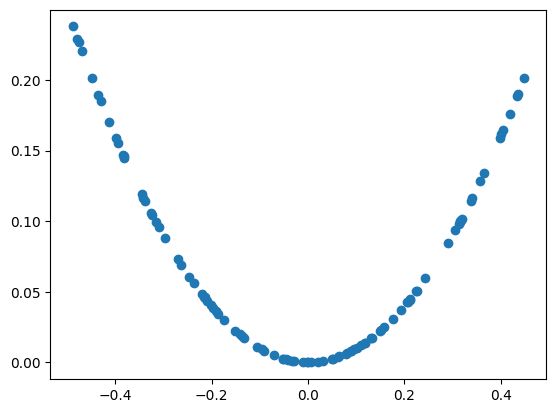

Starting Training...
Epoch 2000: [D loss: 1.1067] [G loss: 0.4101]
> Accuracy Real: 0%, Fake: 0%


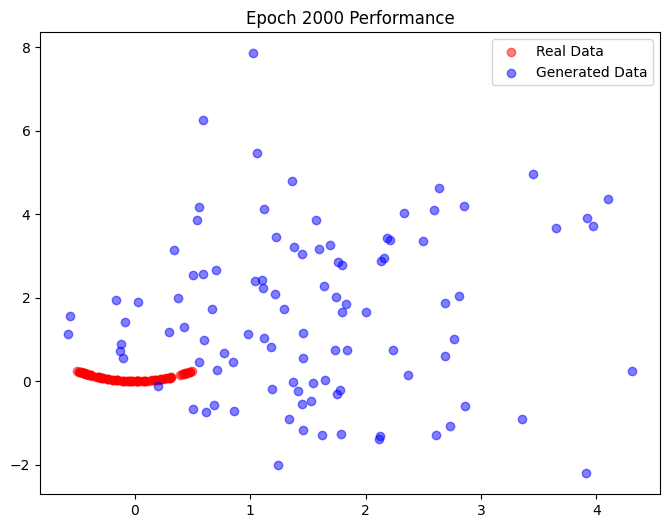

Epoch 4000: [D loss: 1.7714] [G loss: 0.2611]
> Accuracy Real: 0%, Fake: 0%


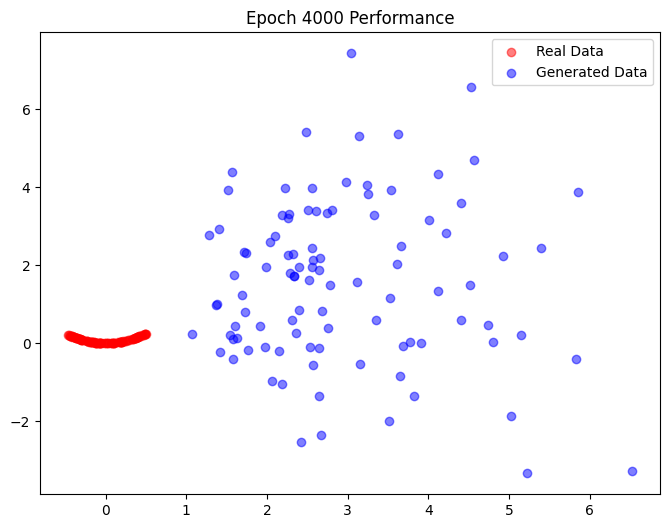

Epoch 6000: [D loss: 2.4789] [G loss: 0.1843]
> Accuracy Real: 0%, Fake: 0%


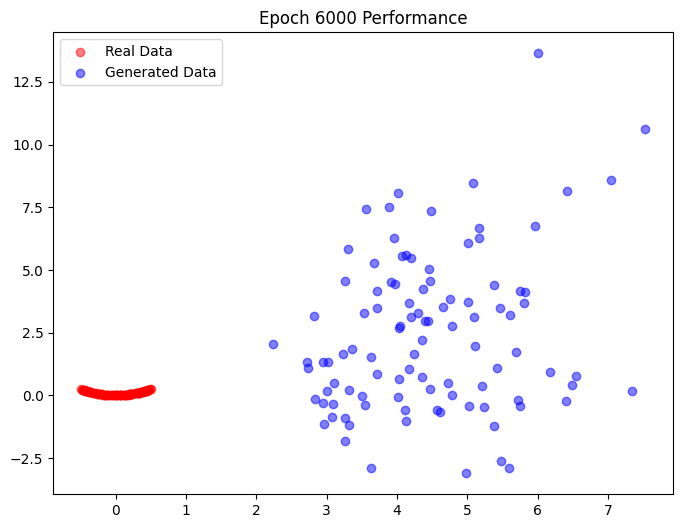

Epoch 8000: [D loss: 3.1504] [G loss: 0.1405]
> Accuracy Real: 0%, Fake: 0%


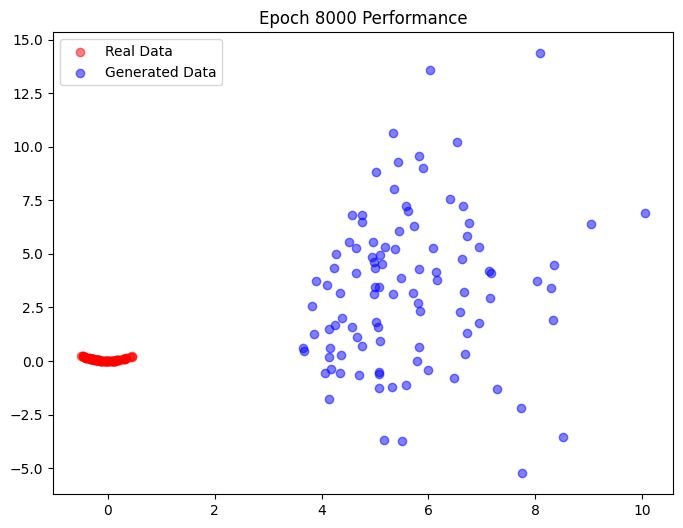

Epoch 10000: [D loss: 3.7942] [G loss: 0.1130]
> Accuracy Real: 0%, Fake: 0%


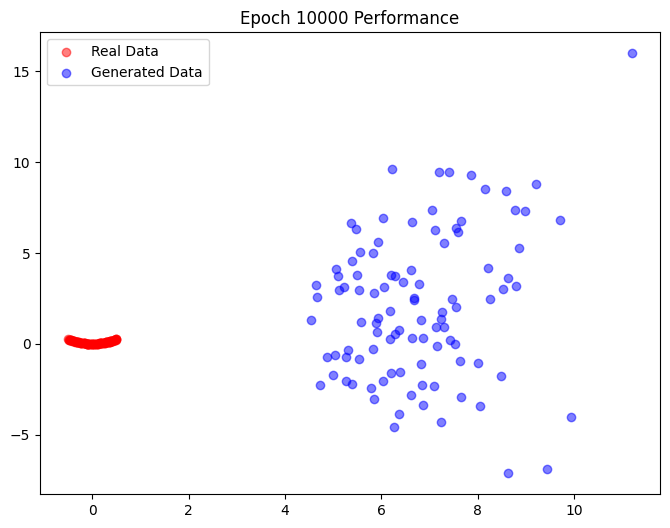

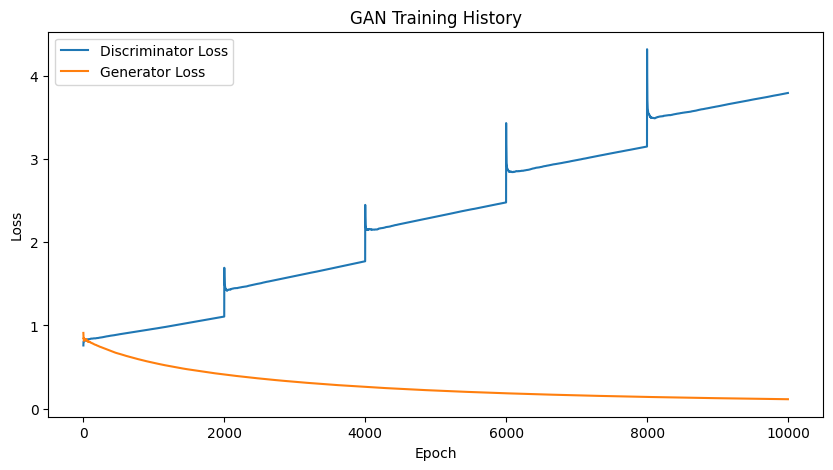

In [3]:
# Hyperparameters
LATENT_DIM = 5
EPOCHS = 10000
BATCH_SIZE = 128
EVAL_FREQ = 2000

real_data = generate_real_samples(100, -0.5, 0.5)
plt.scatter(real_data[0][:, 0], real_data[0][:, 1])
plt.show()

# Build models
discriminator = discriminator_model()
generator = generator_model(latent_dim=LATENT_DIM)
gan = define_gan(generator, discriminator)

# Train
print("Starting Training...")
d_loss_hist, g_loss_hist = train(generator, discriminator, gan, LATENT_DIM, 
                                n_epochs=EPOCHS, n_batch=BATCH_SIZE, 
                                n_eval=EVAL_FREQ)
    
# Plot final loss history
plot_history(d_loss_hist, g_loss_hist)


In [4]:
# visualize the models
#plot_model(discriminator, 
#           to_file='dis_model.png', 
#           show_shapes=True, 
#           show_layer_names=True)
print("\nDiscriminator Model Summary:")
discriminator.summary()
# Visualize Generator
#plot_model(generator, 
#           to_file='gen_model.png', 
#           show_shapes=True, 
#           show_layer_names=True)
print("\nGenerator Model Summary:")
generator.summary()

print("\nGAN Model Summary:")
gan.summary()
#plot_model(gan_model, to_file='gan_plot.png', 
#           show_shapes=True, show_layer_names=True)
        


Discriminator Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 25)             │            75 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 2)              │           122 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 469 (1.84 KB)

 Trainable params: 122 (488.00 B)

 Non-trainable params: 101 (404.00 B)

 Optimizer params: 246 (988.00 B)